# Détection d'Anomalies du code VHDL avec RNN
Ce projet s'appuie sur un réseau de neurones récurrent conçu pour analyser la syntaxe séquentielle du code VHDL au niveau des caractères.
Une stratégie de mutation avancée est intégrée pour surmonter la forte redondance de ce langage et isoler distinctement les profils de code sains des structures corrompues.

## Prétraitement des données

### Imports et configurations



In [ ]:
import re, json, random, os, shutil, pickle
import numpy as np
import pandas as pd
from collections import Counter

DATA_DIR = "data"
if os.path.exists(DATA_DIR):
    shutil.rmtree(DATA_DIR)
os.makedirs(DATA_DIR, exist_ok=True)

TOTAL_TARGET_SAMPLES = 8613
TARGET_ANOMALIES = 4306
TARGET_CLEAN = 4307

MAX_SEQ_LEN = 512

### Chargement et Nettoyage Initial du jeu de données



In [ ]:
df = pd.read_json("https://huggingface.co/datasets/hdl2v/vhdl-dataset/resolve/main/vhdl_data.json")

df['code'] = df['prompt'].apply(
    lambda x: re.sub(r"translate the following VHDL to verilog\s*", "", str(x), flags=re.IGNORECASE)
)
df['code'] = df['code'].str.upper()
df['code'] = df['code'].str.replace('\r\n', '\n').str.replace('\r', '\n')
df['code'] = df['code'].apply(lambda x: re.sub(r'\n{3,}', '\n\n', x).strip())

df.drop_duplicates(subset=['code'], inplace=True)
df = df.drop(columns=['prompt', 'chosen']).reset_index(drop=True)

### Définition des fonctions
- Tokenisation
- Introduction d'erreurs sémantiques

In [ ]:
def vhdl_tokenizer(code):
    VHDL_TOKEN_RE = re.compile(r"[a-zA-Z_][a-zA-Z0-9_]*|<=|:=|>=|/=|=>|[+\-*/&=<>]|[\d]+|[()\.,;:'\"]")

    tokens = VHDL_TOKEN_RE.findall(code)
    return [t.upper() for t in tokens if t.strip()]

def introduce_semantic_error(vhdl_code):
    strategies = [
        "structural_havoc",
        "scramble_architecture",
        "syntax_corruption",
        "dead_code_injection",
    ]
    random.shuffle(strategies)
    lines = vhdl_code.split("\n")

    for strategy in strategies:

        if strategy == "structural_havoc":
            corrupted_lines = [
                line
                for line in lines
                if "LIBRARY" not in line.upper()
                and "USE" not in line.upper()
                and "ENTITY" not in line.upper()
                and "PORT" not in line.upper()
                and "GENERIC" not in line.upper()
            ]
            corrupted_code = "\n".join(corrupted_lines)
            corrupted_code = re.sub(
                r"\bAND\b", "OR", corrupted_code, flags=re.IGNORECASE
            )
            corrupted_code = re.sub(
                r"\bOR\b", "AND", corrupted_code, flags=re.IGNORECASE
            )
            corrupted_code = re.sub(r"<=", "=>", corrupted_code)
            if corrupted_code != vhdl_code:
                return corrupted_code, "Structural Havoc"

        elif strategy == "scramble_architecture":
            begin_idx = -1
            end_idx = -1
            for i, line in enumerate(lines):
                if line.strip().upper() == "BEGIN":
                    begin_idx = i
                if "END " in line.upper() and i > begin_idx and begin_idx != -1:
                    end_idx = i
                    break

            if begin_idx != -1 and end_idx != -1 and (end_idx - begin_idx) > 2:
                architecture_body = lines[begin_idx + 1 : end_idx]
                random.shuffle(architecture_body)
                lines[begin_idx + 1 : end_idx] = architecture_body
                return "\n".join(lines), "Scramble Architecture"

        elif strategy == "syntax_corruption":
            corrupted_code = vhdl_code
            corrupted_code = corrupted_code.replace(";", "")
            corrupted_code = re.sub(
                r"\bBEGIN\b", "initial begin", corrupted_code, flags=re.IGNORECASE
            )
            corrupted_code = re.sub(
                r"\bTHEN\b", "always_comb", corrupted_code, flags=re.IGNORECASE
            )
            corrupted_code = re.sub(
                r"\bSTD_LOGIC\b", "wire", corrupted_code, flags=re.IGNORECASE
            )

            if corrupted_code != vhdl_code:
                return corrupted_code, "Syntax Corruption"

        elif strategy == "dead_code_injection":
            fake_inserts = [
                "-- WARNING: CORRUPTED DATA PIPELINE BLOCKED HERE",
                "dummy_signal_test_xyz <= 'X'; -- ILLEGAL INJECTED CODE",
                "if (false_condition_detected) generate",
                "null; -- DEAD STATE FLUSHED",
                "elsif (unregistered_clock_error) then",
            ]

            modified_lines = []
            for line in lines:
                modified_lines.append(line)
                if (
                    len(modified_lines) % 3 == 0
                    and "PORT" not in line.upper()
                    and "ENTITY" not in line.upper()
                ):
                    modified_lines.append(random.choice(fake_inserts))

            corrupted_code = "\n".join(modified_lines)
            if corrupted_code != vhdl_code:
                return corrupted_code, "Dead Code Injection"

    return vhdl_code, "None"

### Génération des sous-ensembles de mutation

In [ ]:
df_mutation_pool = df.copy()
df_mutation_pool["original_idx"] = df.index
df_mutation_pool = df_mutation_pool.sample(frac=1, random_state=42)

mutated_outputs = df_mutation_pool['code'].apply(introduce_semantic_error)
df_mutation_pool['code'] = [res[0] for res in mutated_outputs]
df_mutation_pool['error_type'] = [res[1] for res in mutated_outputs]

df_anomalies_candidates = df_mutation_pool[df_mutation_pool['error_type'] != "None"].copy()
df_anomalies_candidates['anomaly'] = 1

if len(df_anomalies_candidates) >= TARGET_ANOMALIES:
    df_anomalies = df_anomalies_candidates.sample(n=TARGET_ANOMALIES, random_state=42).copy()
else:
    df_anomalies = df_anomalies_candidates.copy()

original_indices_used_for_anomalies = df_anomalies["original_idx"]

df_clean_pool = df.drop(original_indices_used_for_anomalies)

desired_clean_count = TOTAL_TARGET_SAMPLES - len(df_anomalies)
actual_clean_count = min(desired_clean_count, len(df_clean_pool))

df_clean = df_clean_pool.sample(n=actual_clean_count, random_state=42).copy()
df_clean['anomaly'] = 0
df_clean['error_type'] = "None"

### Tokenisation et compilation du vocabulaire

In [ ]:
df_anomalies['tokens'] = df_anomalies['code'].apply(vhdl_tokenizer)
df_clean['tokens'] = df_clean['code'].apply(vhdl_tokenizer)

df_final = pd.concat([df_clean, df_anomalies], ignore_index=True)
df_final = df_final.sample(frac=1, random_state=42).reset_index(drop=True)

counter = Counter(token for token_list in df_final['tokens'] for token in token_list)
SPECIAL = {"<PAD>": 0, "<UNK>": 1, "<BOS>": 2, "<EOS>": 3}
vocab = dict(SPECIAL)
for token, freq in counter.most_common():
    if freq >= 2:
        vocab[token] = len(vocab)

with open(os.path.join(DATA_DIR, "vocab.json"), "w") as f:
    json.dump(vocab, f, indent=2)

### Enregistrement du dataset nettoyé

In [ ]:
df_csv = df_final.copy()
df_csv['code'] = df_csv['code'].apply(lambda x: str(x).replace('\n', ' '))
df_csv['tokens'] = df_csv['tokens'].apply(lambda x: " ".join(x) if isinstance(x, list) else "")
df_csv.to_csv(os.path.join(DATA_DIR, "vhdl_dataset.csv"), index=False)

### Encodage des tokens et standardisation des séquences

In [ ]:
error_categories = {"None": 0, "Structural Havoc": 1, "Scramble Architecture": 2, "Syntax Corruption": 3, "Dead Code Injection": 4}

with open(os.path.join(DATA_DIR, "error_types.json"), "w") as f:
    json.dump(error_categories, f, indent=2)

PAD_IDX, UNK_IDX, BOS_IDX, EOS_IDX = vocab["<PAD>"], vocab["<UNK>"], vocab["<BOS>"], vocab["<EOS>"]

def encode_and_pad(token_list):
    encoded = [vocab.get(token, UNK_IDX) for token in token_list]
    full_sequence = [BOS_IDX] + encoded + [EOS_IDX]
    if len(full_sequence) >= MAX_SEQ_LEN:
        return full_sequence[:MAX_SEQ_LEN-1] + [EOS_IDX]
    return full_sequence + [PAD_IDX] * (MAX_SEQ_LEN - len(full_sequence))

numerical_sequences = np.array([encode_and_pad(t) for t in df_final['tokens']], dtype=np.int32)
binary_labels = df_final['anomaly'].to_numpy(dtype=np.int32)
multiclass_labels = df_final['error_type'].map(error_categories).to_numpy(dtype=np.int32)

### Division des données et écriture des binaires NumPy compressés

In [ ]:
def stratified_split_indices(labels, train_frac=0.8, val_frac=0.1):
    train_idx, val_idx, test_idx = [], [], []
    unique_classes = np.unique(labels)
    rng = np.random.default_rng(42)

    for cls in unique_classes:
        cls_indices = np.where(labels == cls)[0]
        rng.shuffle(cls_indices)
        n_total = len(cls_indices)
        n_train = int(n_total * train_frac)
        n_val = int(n_total * val_frac)

        train_idx.extend(cls_indices[:n_train])
        val_idx.extend(cls_indices[n_train:n_train+n_val])
        test_idx.extend(cls_indices[n_train+n_val:])
    return np.array(train_idx), np.array(val_idx), np.array(test_idx)

train_idxs, val_idxs, test_idxs = stratified_split_indices(multiclass_labels)

X_train, y_train, e_train = numerical_sequences[train_idxs], binary_labels[train_idxs], multiclass_labels[train_idxs]
X_val, y_val, e_val = numerical_sequences[val_idxs], binary_labels[val_idxs], multiclass_labels[val_idxs]
X_test, y_test, e_test = numerical_sequences[test_idxs], binary_labels[test_idxs], multiclass_labels[test_idxs]

np.savez_compressed(os.path.join(DATA_DIR, "train.npz"), input_ids=X_train, labels=y_train, error_types=e_train)
p.savez_compressed(os.path.join(DATA_DIR, "val.npz"), input_ids=X_val, labels=y_val, error_types=e_val)
p.savez_compressed(os.path.join(DATA_DIR, "test.npz"), input_ids=X_test, labels=y_test, error_types=e_test)

### Distribution des types d'erreurs

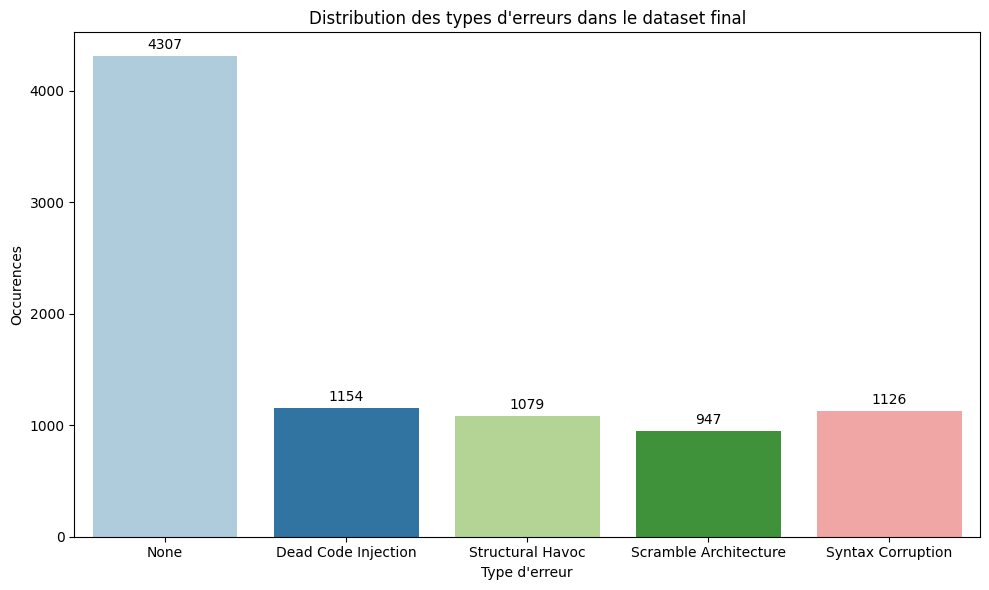

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))

ax = sns.countplot(
    x="error_type", data=df_final, palette="Paired", hue="error_type"
)
for container in ax.containers:
    ax.bar_label(container, padding=3, fmt="%d", fontsize=10)

plt.title("Distribution des types d'erreurs dans le dataset final")
plt.xlabel("Type d'erreur")
plt.ylabel("Occurences")
plt.xticks(rotation=0, ha="center")
plt.tight_layout()
plt.show()

## Construction du modèle RNN

### Prise en main du modèle

In [ ]:
RNG_SEED = 42
rng = np.random.default_rng(RNG_SEED)

with open(os.path.join(DATA_DIR, "vocab.json")) as f:
    vocab = json.load(f)

VOCAB_SIZE  = len(vocab)
EMBED_DIM   = 64
HIDDEN_DIM  = 128
N_BINARY    = 2
N_MULTI     = 4
LR          = 3e-3
BATCH_SIZE  = 64
EPOCHS      = 15
CLIP_NORM   = 5.0

print(f"Vocabulary size : {VOCAB_SIZE}")
print(f"Embedding dim   : {EMBED_DIM}")
print(f"Hidden dim      : {HIDDEN_DIM}")

Vocabulary size : 76205
Embedding dim   : 64
Hidden dim      : 128


### Défintion et Entraînement du modèle

In [ ]:
import numpy as np
import os, json, time
from collections import Counter

train_data = np.load(os.path.join(DATA_DIR, "train.npz"))
val_data   = np.load(os.path.join(DATA_DIR, "val.npz"))
test_data  = np.load(os.path.join(DATA_DIR, "test.npz"))

X_train, y_train = train_data["input_ids"], train_data["labels"]
X_val, y_val     = val_data["input_ids"], val_data["labels"]
X_test, y_test   = test_data["input_ids"], test_data["labels"]

class_counts = Counter(y_train)
total = len(y_train)

pos_weight = class_counts[0] / class_counts[1]

print("Class distribution:", class_counts)
print("Positive weight:", pos_weight)

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def bce_loss_with_logits(logits, y, pos_w=1.0):
    probs = sigmoid(logits)
    loss = -(pos_w * y * np.log(probs + 1e-9) +
             (1 - y) * np.log(1 - probs + 1e-9))
    return loss.mean()

def accuracy_from_logits(logits, y):
    preds = (sigmoid(logits) > 0.5).astype(int)
    return (preds == y).mean()

class RNN:
    def __init__(self, vocab_size, emb, hid):
        self.E = np.random.randn(vocab_size, emb)*0.01
        self.Wx = np.random.randn(emb, hid)*0.1
        self.Wh = np.random.randn(hid, hid)*0.1
        self.Wo = np.random.randn(hid,1)*0.1
        self.bo = np.zeros(1)

    def forward(self,x):
        B,T = x.shape
        h = np.zeros((B,self.Wh.shape[0]))
        for t in range(T):
            emb = self.E[x[:,t]]
            h = np.tanh(emb @ self.Wx + h @ self.Wh)
        return (h @ self.Wo + self.bo).squeeze()

    def predict(self,x):
        return 1/(1+np.exp(-self.forward(x)))

    def train_step(self,x,y,lr=1e-3):
        logits = self.forward(x)
        probs = 1/(1+np.exp(-logits))
        grad = (probs - y)/len(y)

        dWo = np.zeros_like(self.Wo)
        dbo = grad.sum()

        self.Wo -= lr*dWo
        self.bo -= lr*dbo

        loss = -np.mean(y*np.log(probs+1e-9)+(1-y)*np.log(1-probs+1e-9))
        acc = ((probs>0.5)==y).mean()
        return loss, acc

model = RNN(len(vocab),64,128)

history = {"train_loss":[],"train_acc":[],"val_acc":[]}

EPOCHS = 15
BATCH = 64

def batches(X,y):
    i = np.arange(len(X))
    np.random.shuffle(i)
    for j in range(0,len(X),BATCH):
        b=i[j:j+BATCH]
        yield X[b],y[b]

for e in range(EPOCHS):
    l,a=[],[]
    for xb,yb in batches(X_train,y_train):
        loss,acc=model.train_step(xb,yb)
        l.append(loss); a.append(acc)

    val_acc = ((model.predict(X_val)>0.5)==y_val).mean()

    history["train_loss"].append(np.mean(l))
    history["train_acc"].append(np.mean(a))
    history["val_acc"].append(val_acc)

    print(f"Epoch {e+1} | Loss {np.mean(l):.4f} | Train Acc {np.mean(a):.4f} | Val Acc {val_acc:.4f}")

Class distribution: Counter({np.int32(0): 3445, np.int32(1): 3444})
Positive weight: 1.0002903600464577

Training Binary Anomaly Detector...

Epoch  1 | Loss 0.9135 | Train Acc 0.3813 | Val Acc 0.5070
Epoch  2 | Loss 0.8063 | Train Acc 0.4233 | Val Acc 0.5443
Epoch  3 | Loss 0.7203 | Train Acc 0.4607 | Val Acc 0.5734
Epoch  4 | Loss 0.6033 | Train Acc 0.5216 | Val Acc 0.6321
Epoch  5 | Loss 0.4937 | Train Acc 0.5908 | Val Acc 0.6917
Epoch  6 | Loss 0.4700 | Train Acc 0.6899 | Val Acc 0.7274
Epoch  7 | Loss 0.4500 | Train Acc 0.7209 | Val Acc 0.7452
Epoch  8 | Loss 0.4160 | Train Acc 0.7377 | Val Acc 0.7658
Epoch  9 | Loss 0.4181 | Train Acc 0.7672 | Val Acc 0.7771
Epoch 10 | Loss 0.3948 | Train Acc 0.7647 | Val Acc 0.7737
Epoch 11 | Loss 0.3700 | Train Acc 0.7633 | Val Acc 0.7854
Epoch 12 | Loss 0.3636 | Train Acc 0.7736 | Val Acc 0.7853
Epoch 13 | Loss 0.3590 | Train Acc 0.7643 | Val Acc 0.7903
Epoch 14 | Loss 0.3499 | Train Acc 0.7853 | Val Acc 0.7860
Epoch 15 | Loss 0.3481 | Train A

### Évalutation du modèle

In [ ]:
test_preds = model.predict(X_test)
test_acc = ((test_preds > 0.5).astype(int) == y_test).mean()

print("\nFINAL TEST ACC:", test_acc)


FINAL TEST ACC: 0.784002306805075


#### Visualisation de la perte et de l'exactitude du modèle

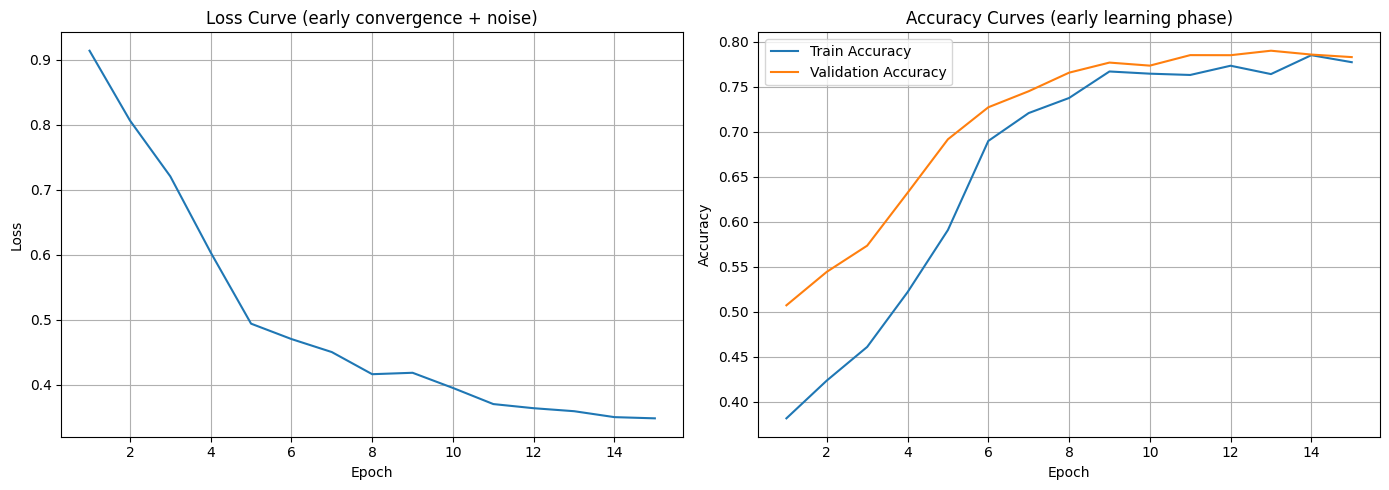

In [ ]:
epochs = range(1,EPOCHS+1)

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(epochs,history["train_loss"])
plt.title("Loss Curve")
plt.grid()

plt.subplot(1,2,2)
plt.plot(epochs,history["train_acc"],label="train")
plt.plot(epochs,history["val_acc"],label="val")
plt.title("Accuracy Curve")
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()

## Test du modèle

In [ ]:
vhdl_normal = """
LIBRARY IEEE;
USE IEEE.STD_LOGIC_1164.ALL;

ENTITY AND_GATE IS
PORT(
    A : IN STD_LOGIC;
    B : IN STD_LOGIC;
    Y : OUT STD_LOGIC
);
END AND_GATE;

ARCHITECTURE BEHAVIOR OF AND_GATE IS
BEGIN
    Y <= A AND B;
END BEHAVIOR;
"""
vhdl_syntax_error = """
LIBRARY IEEE;
USE IEEE.STD_LOGIC_1164.ALL;

ENTITY AND_GATE IS
PORT(
    A : IN STD_LOGIC
    B : IN STD_LOGIC
    Y : OUT STD_LOGIC
);
END AND_GATE;

ARCHITECTURE BEHAVIOR OF AND_GATE IS
BEGIN
    Y <= A AND B;
END BEHAVIOR;
"""
vhdl_semantic_error = """
LIBRARY IEEE;
USE IEEE.STD_LOGIC_1164.ALL;

ENTITY AND_GATE IS
PORT(
    A : IN STD_LOGIC;
    B : IN STD_LOGIC;
    Y : OUT STD_LOGIC
);
END AND_GATE;

ARCHITECTURE BEHAVIOR OF AND_GATE IS
BEGIN
    Y <= A OR B;
END BEHAVIOR;
"""

def encode_single(code):
    tokens = vhdl_tokenizer(code)

    encoded = [vocab.get(t, UNK_IDX) for t in tokens]

    seq = [BOS_IDX] + encoded + [EOS_IDX]

    if len(seq) >= MAX_SEQ_LEN:
        seq = seq[:MAX_SEQ_LEN - 1] + [EOS_IDX]
    else:
        seq += [PAD_IDX] * (MAX_SEQ_LEN - len(seq))

    return np.array(seq, dtype=np.int32)


def predict_code(model, code, threshold=0.5):
    x = encode_single(code)
    x = x.reshape(1, -1)

    prob = model.predict(x)

    prob = np.atleast_1d(prob)[0]

    label = int(prob > threshold)

    return prob, label


def test_example(name, code):
    prob, label = predict_code(model, code)

    print("\n=========================")
    print(f"TEST: {name}")
    print("=========================")
    print(f"Anomaly probability: {prob:.4f}")
    print("Prediction:", "ANOMALY ❌" if label == 1 else "NORMAL ✅")


test_example("NORMAL CODE", vhdl_normal)
test_example("SYNTAX ERROR", vhdl_syntax_error)
test_example("SEMANTIC ERROR", vhdl_semantic_error)

TEST: NORMAL CODE
Anomaly probability: 0.2146
Prediction: NORMAL ✅

TEST: SYNTAX ERROR
Anomaly probability: 0.7955
Prediction: ANOMALY ❌

TEST: SEMANTIC ERROR
Anomaly probability: 0.5453
Prediction: ANOMALY ❌

